In [42]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [43]:
def BalanceTest(G):
    """
    Test whether a signed undirected graph is balanced.
    """

    # Build subgraph containing only positive edges
    G_pos = nx.Graph()
    for u, v, data in G.edges(data=True):
        if data["sign"] == "+":
            G_pos.add_edge(u, v)

    # Identify connected components
    components = list(nx.connected_components(G_pos))

    all_nodes = set(G.nodes())
    nodes_in_pos = set().union(*components) if components else set()
    missing_nodes = all_nodes - nodes_in_pos
    for node in missing_nodes:
        components.append({node})

    # Map each node to its component index
    comp_index = {}
    for i, comp in enumerate(components):
        for node in comp:
            comp_index[node] = i

    # Check for forbidden negative edges inside a group
    for u, v, data in G.edges(data=True):
        if data["sign"] == "-":
            if comp_index[u] == comp_index[v]:
                return False   # violates balance

    # Build the supernode graph using only negative edges
    H = nx.Graph()
    H.add_nodes_from(range(len(components)))

    for u, v, data in G.edges(data=True):
        if data["sign"] == "-":
            cu = comp_index[u]
            cv = comp_index[v]
            if cu != cv:
                H.add_edge(cu, cv)

    # Return True if supernode graph is bipartite
    return nx.is_bipartite(H)


In [ ]:
# Graph from fig 5.8 in textbook

G1 = nx.Graph()
G1.add_nodes_from(range(1, 16))

edges = [
    (1, 2, "+"), 
    (1, 3, "+"),
    (2, 3, "+"),
    (3, 6, "-"),
    (2, 5, "+"), 
    (5, 6, "-"),
    (6, 11, "-"),
    (6, 8, "+"),
    (11, 8, "-"),
    (11, 10, "-"),
    (11, 14, "-"),
    (10, 12, "+"),
    (14, 15, "-"), 
    (15, 13, "-"),
    (11, 13, "-"),
    (12, 13, "+"),
    (12, 7, "+"),
    (12, 9, "+"),
    (7, 4, "-"),
    (9, 4, "-"),
    (4, 2, "-")
]

for u, v, sign in edges:
    G1.add_edge(u, v, sign=sign)


In [ ]:
# Modified graph

G2 = nx.Graph()
G2.add_nodes_from(range(1, 16))

edges = [
    (1, 2, "+"), 
    (1, 3, "+"),
    (2, 3, "+"),
    (3, 6, "-"),
    (2, 5, "+"), 
    (5, 6, "-"),
    (6, 11, "-"),
    (6, 8, "+"),
    (11, 8, "-"),
    (11, 10, "-"),
    (11, 14, "-"),
    (10, 12, "+"),
    (14, 15, "-"), 
    (15, 13, "-"),
    (11, 13, "-"),
    (12, 13, "+"),
    (12, 7, "+"),
    (12, 9, "+"),
    (7, 4, "-"),
    (9, 4, "-"),
    (4, 2, "+") # Now plus
]

for u, v, sign in edges:
    G2.add_edge(u, v, sign=sign)



In [46]:
print(BalanceTest(G1))
print(BalanceTest(G2))

False
True


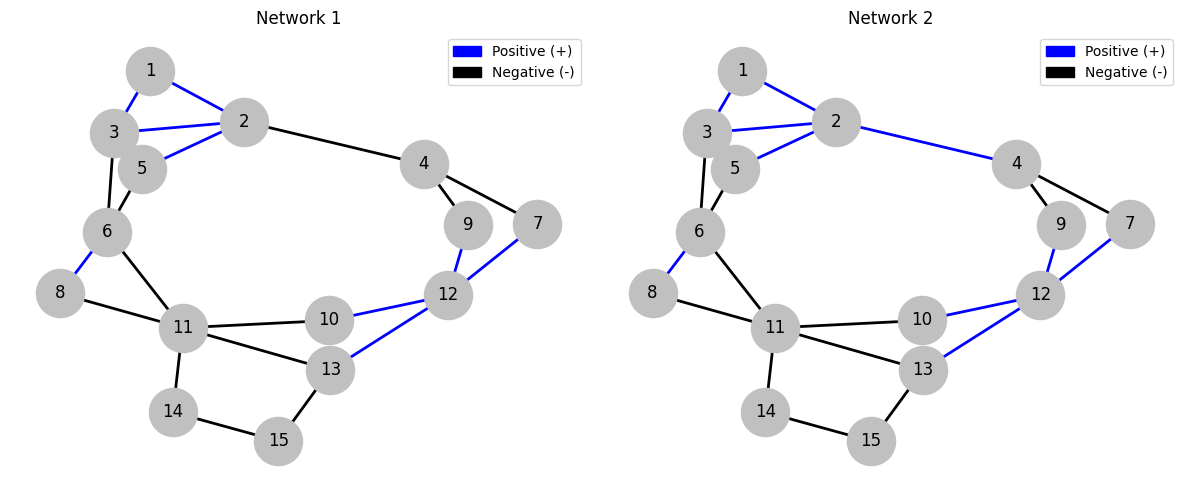

In [52]:
def draw_signed_graph(G, title):
    pos = nx.spring_layout(G, seed=42)

    # Color edges by sign
    edge_colors = [
        "blue" if G[u][v]["sign"] == "+" else "black"
        for u, v in G.edges()
    ]

    nx.draw(
        G, pos,
        with_labels=True,
        node_color="silver",
        edge_color=edge_colors,
        width=2,
        node_size=1200,
        font_size=12
    )


    red_patch = mpatches.Patch(color='black', label='Negative (-)')
    green_patch = mpatches.Patch(color='blue', label='Positive (+)')
    plt.legend(handles=[green_patch, red_patch])
    plt.title(title)


# Plot

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
draw_signed_graph(G1, "Network 1")

plt.subplot(1, 2, 2)
draw_signed_graph(G2, "Network 2")

plt.tight_layout()
plt.show()
